In [23]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd

## Limpieza de datos

In [24]:
df_derrames = pd.read_csv('../data/d2_industri02_08.csv', encoding='latin-1')
df_derrames

,Año,Organismo Subsidiario,Número de derrames,Cantidad reportada (toneladas)
0,1999.0,PEMEX Exploración (PEP),763,"1,501.00"
1,NaN,PEMEX Refinación (PR),93,"1,946.00"
2,NaN,Total,856,"3,447.00"
3,2000.0,PEMEX Exploración (PEP),"1,428","1,097.00"
4,NaN,PEMEX Refinación (PR),90,"5,155.00"
...,...,...,...,...
102,2020.0,"EPS, PEMEX Exploración y Producción",536,"1,510.54"
103,NaN,"EPS, PEMEX Transformación industrial",54,9.18
104,NaN,"EPS, PEMEX Fertilizantes",0,0.00
105,NaN,"EPS, PEMEX Logística \n",102,25.12


In [25]:
# Nos quedamos con los totales por año
df_derrames = df_derrames[df_derrames['Organismo Subsidiario'] == 'Total']
df_derrames['Año'] = range(1999, 2021)
df_derrames

,Año,Organismo Subsidiario,Número de derrames,Cantidad reportada (toneladas)
2,1999,Total,856,"3,447.00"
5,2000,Total,"1,518","6,252.00"
8,2001,Total,523,"5,762.00"
13,2002,Total,378,"19,807.00"
18,2003,Total,431,"4,824.00"
23,2004,Total,517,"5,478.00"
28,2005,Total,359,"2,321.00"
33,2006,Total,277,"3,432.92"
36,2007,Total,206,"1,439.00"
39,2008,Total,171,"2,327.00"


In [29]:
df_derrames = df_derrames.drop(columns=['Organismo Subsidiario'])
df_derrames

,Año,Número de derrames,Cantidad reportada (toneladas)
2,1999,856,"3,447.00"
5,2000,"1,518","6,252.00"
8,2001,523,"5,762.00"
13,2002,378,"19,807.00"
18,2003,431,"4,824.00"
23,2004,517,"5,478.00"
28,2005,359,"2,321.00"
33,2006,277,"3,432.92"
36,2007,206,"1,439.00"
39,2008,171,"2,327.00"


In [33]:
df_turismo = pd.read_csv('../data/pib_turismo_tabasco_campeche_veracruz.csv')
df_turismo

,anio,Tabasco (PBI Turismo),Campeche (PBI Turismo),Veracruz (PBI Turismo)
0,2003,20734.72885,12791.82474,58265.34516
1,2004,21407.57126,13106.11582,60023.95003
2,2005,21225.32855,12965.67334,59455.50040
3,2006,21185.30421,13031.83574,59424.48395
4,2007,21391.63097,13353.89335,60122.44814
5,2008,20918.09550,13443.95400,59026.92042
6,2009,20609.60381,12536.24370,59009.58454
7,2010,21360.37265,12453.38194,61787.88543
8,2011,22586.63298,12826.78913,65761.47932
9,2012,24066.83210,13523.19669,70467.00459


In [37]:
df = pd.merge(df_turismo, df_derrames, left_on='anio', right_on='Año')
df = df.drop(columns=['Año'])
df

,anio,Tabasco (PBI Turismo),Campeche (PBI Turismo),Veracruz (PBI Turismo),Número de derrames,Cantidad reportada (toneladas)
0,2003,20734.72885,12791.82474,58265.34516,431,"4,824.00"
1,2004,21407.57126,13106.11582,60023.95003,517,"5,478.00"
2,2005,21225.32855,12965.67334,59455.50040,359,"2,321.00"
3,2006,21185.30421,13031.83574,59424.48395,277,"3,432.92"
4,2007,21391.63097,13353.89335,60122.44814,206,"1,439.00"
5,2008,20918.09550,13443.95400,59026.92042,171,"2,327.00"
6,2009,20609.60381,12536.24370,59009.58454,123,"65,332.00"
7,2010,21360.37265,12453.38194,61787.88543,72,"9,373.00"
8,2011,22586.63298,12826.78913,65761.47932,106,"7,225.00"
9,2012,24066.83210,13523.19669,70467.00459,182,"48,597.00"


In [38]:
df.to_csv('turismo_derrames.csv', index=False)

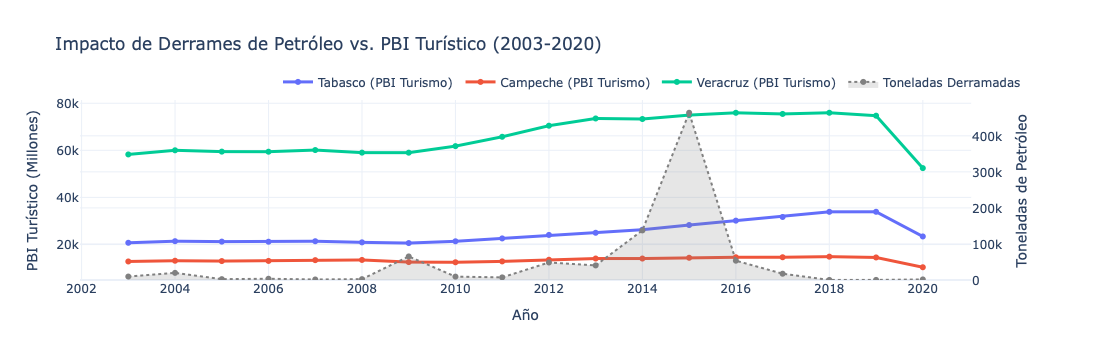

In [1]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd

# Cargar datos
df = pd.read_csv('../data/df_turismo_derrames.csv')

# Crear figura con eje secundario
fig = make_subplots(specs=[[{"secondary_y": True}]])

# 1. Agregar líneas de PBI por estado (Eje Y Primario)
estados = ['Tabasco (PBI Turismo)', 'Campeche (PBI Turismo)', 'Veracruz (PBI Turismo)']
colores = ['#636EFA', '#EF553B', '#00CC96']

for estado, color in zip(estados, colores):
    fig.add_trace(
        go.Scatter(x=df['anio'], y=df[estado], name=estado,
                   line=dict(width=3, color=color), mode='lines+markers'),
        secondary_y=False,
    )

# 2. Agregar el impacto de derrames (Eje Y Secundario)
# Usamos un gráfico de área para que resalte visualmente como un "evento" de fondo
fig.add_trace(
    go.Scatter(x=df['anio'], y=df['cantidad total de toneladas'], 
               name='Toneladas Derramadas',
               fill='tozeroy', fillcolor='rgba(128, 128, 128, 0.2)',
               line=dict(color='gray', dash='dot')),
    secondary_y=True,
)

# Configuración de diseño
fig.update_layout(
    title='Impacto de Derrames de Petróleo vs. PBI Turístico (2003-2020)',
    xaxis_title='Año',
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    template='plotly_white',
    hovermode='x unified'
)

# Nombres de ejes
fig.update_yaxes(title_text="PBI Turístico (Millones)", secondary_y=False)
fig.update_yaxes(title_text="Toneladas de Petróleo", secondary_y=True)

fig.show()